# chronic kidney disease Data Ingestion


This notebook loads in the data from the Chronic kIdney Disease (dataset 2) dataset into a pandas dataframe and performs basic data cleaning and validation

## Ingesting and Visualizing

In [21]:
#Required libraries
import os

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

print("All libraries successfully retrieved.")

All libraries successfully retrieved.


In [22]:
path = "../../data/raw/dataset_1.csv"

try:
    CKD_df = pd.read_csv(path)
except Exception as e:
    print("Error: ", e)

print(f"File: {path} loaded successfully \n")
CKD_df.head(5)

File: ../../data/raw/dataset_1.csv loaded successfully 



,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


### Give a breakdown of all nulls present


In [23]:
print('Standard NaN missing values:')
print(CKD_df.isnull().sum())

Standard NaN missing values:
id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


### Lets Get An Idea of the Initial Classifications For Chronic Kidney Disease

In [24]:
#Overview of the distribution of CKD in the dataset
print('Chronic Kidney Disease distribution:')
print(CKD_df['classification'].value_counts())
print()
print('Proportions:')
print(CKD_df['classification'].value_counts(normalize=True).round(4))


Chronic Kidney Disease distribution:
classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

Proportions:
classification
ckd       0.620
notckd    0.375
ckd\t     0.005
Name: proportion, dtype: float64


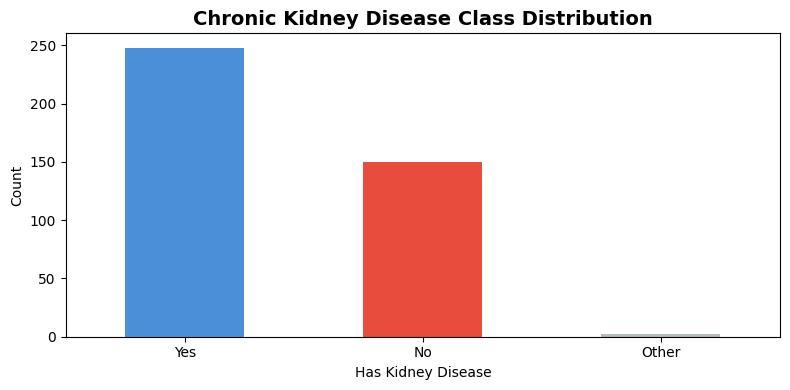

In [25]:
# Visualize class balance
fig, ax = plt.subplots(figsize=(8, 4))
CKD_df['classification'].value_counts().plot(kind='bar', color=['#4A90D9', '#E74C3C', '#B2BEB5'], ax=ax)

ax.set_xticklabels(['Yes', 'No', 'Other'], rotation=0)

ax.set_title('Chronic Kidney Disease Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Has Kidney Disease')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


## Data Preprocessing

In [26]:
#Replace any NaNs with ? for proper processing by sk learn
CKD_df = CKD_df.replace('?', np.nan)

# Check missing value percentages
print("Missing values replaced with '?'")
print(f'Total rows affected: {CKD_df.isnull().any(axis=1).sum()}')
CKD_df.head()

Missing values replaced with '?'
Total rows affected: 242


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [27]:
#Keep only ckd and notckd classes, and drop any other classes if present
CKD_df = CKD_df[CKD_df['classification'].isin(['ckd', 'notckd'])].copy()

#Standardize target name and mapping
CKD_df = CKD_df.rename(columns={'classification': 'target'})

#Explicit mapping: 1 = CKD, 0 = No CKD
CKD_df['target'] = CKD_df['target'].map({
    'ckd': 1,
    'notckd': 0
})

print("Target distribution after mapping:")
print(CKD_df['target'].value_counts())

Target distribution after mapping:
target
1    248
0    150
Name: count, dtype: int64


In [28]:
import os

path = "../../data/cleaned/dataset_1"
os.makedirs(path, exist_ok=True)

#Save cleaned dataset 
CKD_df.to_csv(f"{path}/dataset_1_clean.csv", index=False)

print(f"Cleaned Dataset 1 saved to: {path}/dataset_1_clean.csv")
print("Shape:", CKD_df.shape)
print("Columns:", CKD_df.columns.tolist())

Cleaned Dataset 1 saved to: ../../data/cleaned/dataset_1/dataset_1_clean.csv
Shape: (398, 26)
Columns: ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'target']
